<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 14, accumulation steps = 1 (effective batch size ≈ 14, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.1316 acc 0.495 | val loss 0.8352 acc 0.591 *


[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 1.0280 acc 0.514 | val loss 1.0580 acc 0.493


[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.8380 acc 0.628 | val loss 0.7276 acc 0.675 *


[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.6831 acc 0.705 | val loss 0.5465 acc 0.793 *


[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.7098 acc 0.684 | val loss 0.7477 acc 0.709


...

[DenseNet-121] Epoch  24/100 | LR: 2.74e-07 | train loss 0.1284 acc 0.931 | val loss 0.3836 acc 0.882


[DenseNet-121] Epoch  25/100 | LR: 2.74e-07 | train loss 0.1693 acc 0.912 | val loss 0.4038 acc 0.862


[DenseNet-121] Epoch  26/100 | LR: 2.74e-07 | train loss 0.1220 acc 0.924 | val loss 0.4350 acc 0.867


[DenseNet-121] Epoch  27/100 | LR: 2.74e-07 | train loss 0.1743 acc 0.919 | val loss 0.4326 acc 0.852


[DenseNet-121] Epoch  28/100 | LR: 2.74e-08 | train loss 0.1327 acc 0.923 | val loss 0.4306 acc 0.862

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 28.

[DenseNet-121] Restored best checkpoint (val loss = 0.3673)


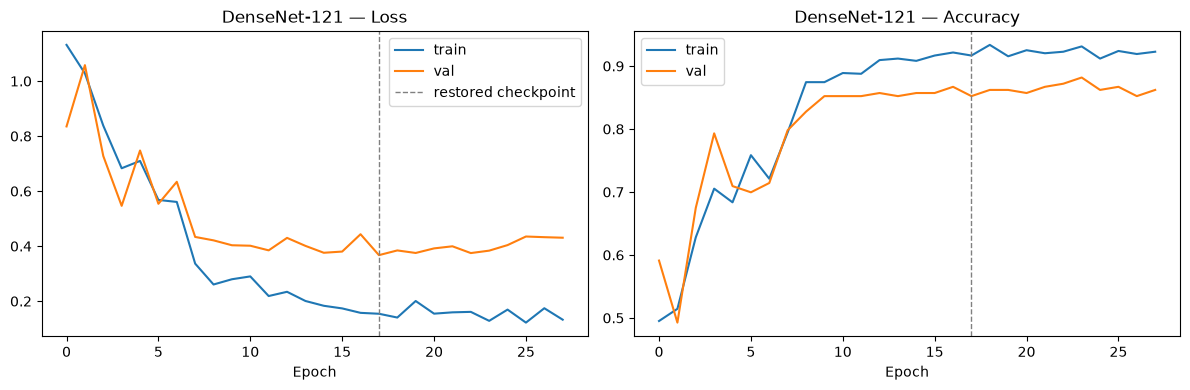

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.687


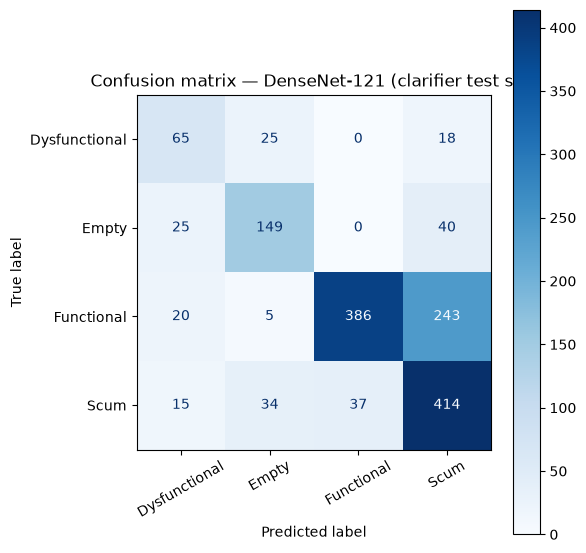

               precision    recall  f1-score   support

Dysfunctional      0.520     0.602     0.558       108
        Empty      0.700     0.696     0.698       214
   Functional      0.913     0.590     0.717       654
         Scum      0.579     0.828     0.681       500

     accuracy                          0.687      1476
    macro avg      0.678     0.679     0.664      1476
 weighted avg      0.740     0.687     0.690      1476



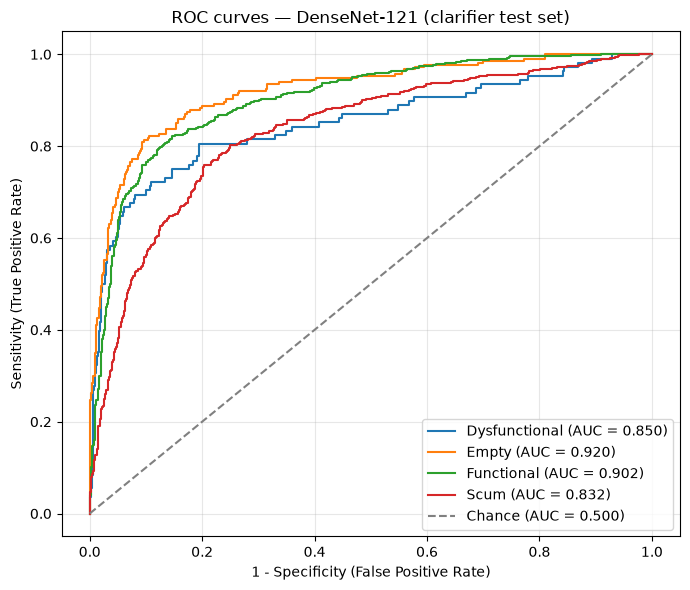

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.850
  Empty          : 0.920
  Functional     : 0.902
  Scum           : 0.832

Mean AUC (over 4/4 classes with test examples): 0.876


(np.float64(0.6869918699186992),
 {'Dysfunctional': 0.8498822287199481,
  'Empty': 0.9195239717404506,
  'Functional': 0.9017649203479244,
  'Scum': 0.8322151639344263})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_CapeFlats.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
